In [1]:
from sentence_transformers import SentenceTransformer, util

C:\Users\USER\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load a free model
model = SentenceTransformer('all-MiniLM-L6-v2')

In [3]:
#mini dataset
texts = {
    "philosophy_truth": "The unexamined life is not worth living. - Socrates",
    "pop_truth": "No cap, that’s the truth lol",
    "philosophy_freedom": "Man is condemned to be free. - Sartre",
    "pop_freedom": "Finally freeee, weekend vibes!",
}

In [4]:
# Encode
embeddings = {k: model.encode(v, convert_to_tensor=True) for k,v in texts.items()}

In [5]:
# Compare similarities
sim = util.cos_sim(embeddings["philosophy_truth"], embeddings["pop_truth"])
print("Truth (philosophy vs pop):", sim.item())

sim2 = util.cos_sim(embeddings["philosophy_freedom"], embeddings["pop_freedom"])
print("Freedom (philosophy vs pop):", sim2.item())

Truth (philosophy vs pop): 0.01920202001929283
Freedom (philosophy vs pop): 0.18179868161678314


Cosine similarity score ranges from -1 to 1.

1 → texts are very similar in meaning.

0 → not really related.

-1 → completely opposite.

Your results:

Truth (0.019) → basically unrelated. The model sees Socrates’ “unexamined life” as very different from “No cap, that’s the truth lol.”

Freedom (0.18) → still weakly related, but slightly closer than the truth pair. (The word “free” overlaps, even though meaning differs.)

let's expand the dataset a little more

In [6]:
texts = {
    "philosophy_truth1": "The unexamined life is not worth living. - Socrates",
    "philosophy_truth2": "Even if you are a minority of one, the truth is the truth. - Gandhi",
    "pop_truth1": "No cap, that’s the truth lol",
    "pop_truth2": "Big facts only 🔥",
    "philosophy_freedom1": "Man is condemned to be free. - Sartre",
    "philosophy_freedom2": "Liberty means responsibility. - George Bernard Shaw",
    "pop_freedom1": "Finally freeee, weekend vibes!",
    "pop_freedom2": "Financial freedom is the goal 💸",
}

Compare the above across all pairs

In [7]:
import itertools

keys = list(texts.keys())
for a, b in itertools.combinations(keys, 2):
    sim = util.cos_sim(model.encode(texts[a], convert_to_tensor=True),
                       model.encode(texts[b], convert_to_tensor=True))
    print(f"{a} vs {b}: {sim.item():.3f}")

philosophy_truth1 vs philosophy_truth2: 0.242
philosophy_truth1 vs pop_truth1: 0.019
philosophy_truth1 vs pop_truth2: 0.024
philosophy_truth1 vs philosophy_freedom1: 0.434
philosophy_truth1 vs philosophy_freedom2: 0.420
philosophy_truth1 vs pop_freedom1: 0.061
philosophy_truth1 vs pop_freedom2: 0.269
philosophy_truth2 vs pop_truth1: 0.061
philosophy_truth2 vs pop_truth2: 0.259
philosophy_truth2 vs philosophy_freedom1: 0.280
philosophy_truth2 vs philosophy_freedom2: 0.360
philosophy_truth2 vs pop_freedom1: -0.027
philosophy_truth2 vs pop_freedom2: 0.202
pop_truth1 vs pop_truth2: 0.112
pop_truth1 vs philosophy_freedom1: 0.034
pop_truth1 vs philosophy_freedom2: -0.006
pop_truth1 vs pop_freedom1: 0.022
pop_truth1 vs pop_freedom2: 0.207
pop_truth2 vs philosophy_freedom1: 0.027
pop_truth2 vs philosophy_freedom2: 0.061
pop_truth2 vs pop_freedom1: 0.053
pop_truth2 vs pop_freedom2: 0.234
philosophy_freedom1 vs philosophy_freedom2: 0.457
philosophy_freedom1 vs pop_freedom1: 0.182
philosophy_free

Visualize them

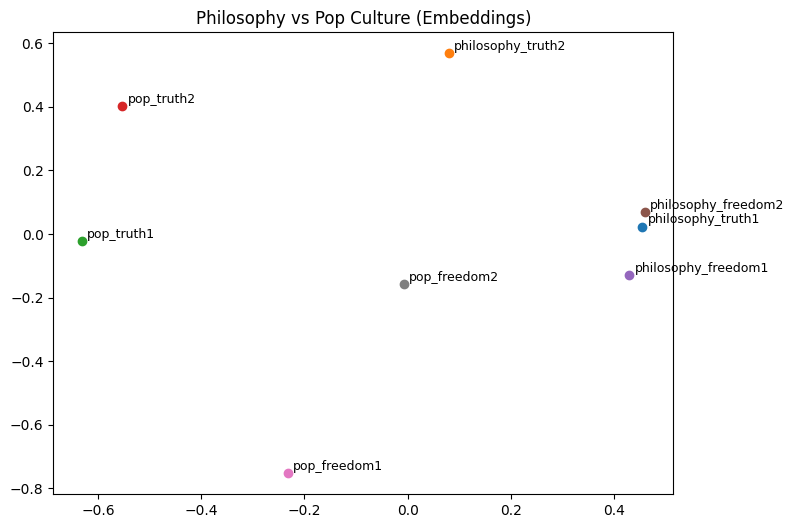

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

embeddings = [model.encode(v) for v in texts.values()]
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
for i, (label, vec) in enumerate(zip(texts.keys(), reduced)):
    plt.scatter(vec[0], vec[1])
    plt.text(vec[0]+0.01, vec[1]+0.01, label, fontsize=9)
plt.title("Philosophy vs Pop Culture (Embeddings)")
plt.show()


C:\Users\USER\venv\Lib\site-packages\sentence_transformers\util.py:55: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  a = torch.tensor(a)


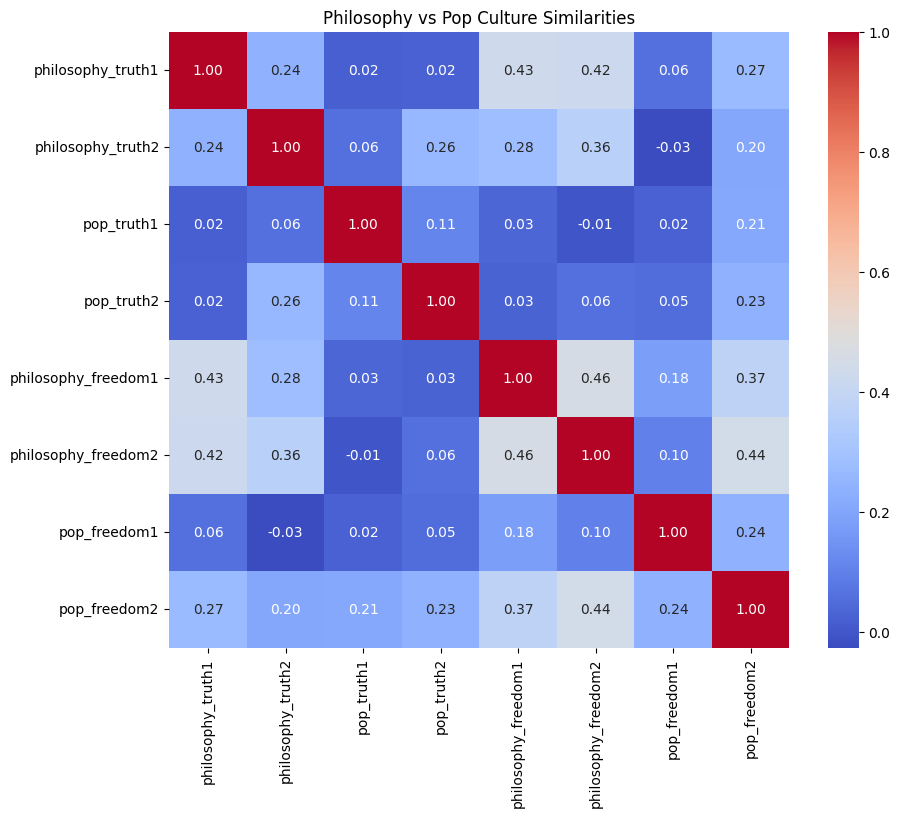

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Encode all texts
embeddings = [model.encode(texts[k]) for k in keys]

# Compute similarity matrix
sim_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(sim_matrix, xticklabels=keys, yticklabels=keys, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Philosophy vs Pop Culture Similarities")
plt.show()
